In [48]:
print("Test")

Test


In [49]:
# Imports
import sys
import pathlib

# Add the project's root directory to the Python path
sys.path.append(pathlib.Path("../").resolve().as_posix())

# Configurations
seed = 42

# Paths
DATA_DIR = pathlib.Path("../data/")
ENC2017_ROOT = DATA_DIR / "enc2017"
UD_ET_EDT_ROOT = DATA_DIR / "ud_et_edt"
HOMONYMS_ROOT = DATA_DIR / "homonymous_word_forms"

ENC2017_DIRS = {
    "processed": ENC2017_ROOT / "processed",
    "raw": ENC2017_ROOT / "raw",
}

UD_ET_EDT_DIRS = {
    "processed": UD_ET_EDT_ROOT / "processed",
    "raw": UD_ET_EDT_ROOT / "raw",
}

HOMONYMS_DIRS = {
    "processed": HOMONYMS_ROOT / "processed",
    "annotations": HOMONYMS_ROOT / "annotations",
}

OUTPUT_DIR = pathlib.Path("../outputs/")

MODEL_DIR = pathlib.Path("../models/")

In [50]:
import sys
import os
import pandas as pd
import json
import pathlib
import numpy as np
import torch

from scripts.model.utils import initialize_model
from scripts.model.train import train_token_classification

In [ ]:
# train_path = HOMONYMS_DIRS["processed"] / "homonyms_overall_updated.parquet"
train_path = HOMONYMS_DIRS["processed"] / "homonyms_train_80.parquet"
eval_path = UD_ET_EDT_DIRS["processed"] / "UD_edt_dev.parquet"
model_dir = "../models/NER_mudel_v2/"
output_dir = "../models/NER_mudel_v2_homonym_80_finetune/"
ignore_placeholders = True
dry_run = False
seed = 42
train_batch_size = 8
learning_rate = 5e-6  # 5e-7 for fine-tuning
num_train_epochs = 10
use_cuda = torch.cuda.is_available()

In [ ]:
train_df = pd.read_parquet(train_path) if train_path else None
eval_df = pd.read_parquet(eval_path) if eval_path else None

# Read labels from the unique labels json
with open("../outputs/unique_labels_old.json", "r") as f:
    unique_labels = json.load(f)

model_bundle = initialize_model(
    str(model_dir),
    unique_labels=unique_labels,
    use_Roberta_tokenizer=False,
    use_fast_tokenizer=False,
    cleanup=True,
)

E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\utils.py:99: UserWarning: Using label mapping from model `id2label` in checkpoint.
  warnings.warn("Using label mapping from model `id2label` in checkpoint.")


In [ ]:
if train_df is not None:
    print(len(train_df))
    display(train_df.head())
if eval_df is not None:
    print(len(eval_df))
    display(eval_df.head())

179986


,sentence_id,words,form,pos,labels,infl_type,source
0,0,Edinburghi,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,0,agulite,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,0,mehe,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,0,Irvine,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,0,Welshi,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


43997


,sentence_id,words,form,pos,labels,file_prefix,source
0,0,Aga,,J,J,aja_ee199920,et_edt-ud-dev_000.json
1,0,mulle,sg all,P,sg all_P,aja_ee199920,et_edt-ud-dev_000.json
2,0,tundub,b,V,b_V,aja_ee199920,et_edt-ud-dev_000.json
3,0,",",,Z,Z,aja_ee199920,et_edt-ud-dev_000.json
4,0,et,,J,J,aja_ee199920,et_edt-ud-dev_000.json


In [ ]:
# Replace labels that contain "T" with placeholder dash "-"
if eval_df is not None:
    eval_df["labels"] = eval_df["labels"].apply(
        lambda label: "-" if ignore_placeholders and "T" in label else label
    )

In [24]:
res = train_token_classification(
    model=model_bundle["model"],
    tokenizer=model_bundle["tokenizer"],
    train_df=train_df,
    label_list=unique_labels,
    output_dir=output_dir,
    eval_df=eval_df if eval_df is not None else None,
    num_train_epochs=num_train_epochs,
    train_batch_size=train_batch_size,
    learning_rate=learning_rate,
    evaluate_during_training=False if eval_df is None else True,
    use_early_stopping=False,
    patience_n=1,
    early_stopping_method="f1",
    early_stopping_threshold=0.8,
    best_model_dir=os.path.join(output_dir, "best_model"),
    save_model_every_epoch=True,
    device=model_bundle["device"],
    silent=False,
    max_length=128,
    ignore_placeholders=ignore_placeholders,
    dry_run=dry_run,
    seed=seed,
)

print("Training finished.")

Epoch 1/10: 100%|██████████| 789/789 [01:07<00:00, 11.61it/s, train_loss=0.4486]


train_loss: 0.4486
Epoch 1 train metrics:
 loss=0.3351,  f1=0.9435,  accuracy=0.9416
Epoch 1 train/eval metrics:
 train_loss=0.3351 | eval_loss=0.1381
 train_f1=0.9435 | eval_f1=0.9782
 train_acc=0.9416 | eval_acc=0.9778


Epoch 2/10: 100%|██████████| 789/789 [01:13<00:00, 10.71it/s, train_loss=0.3098]


train_loss: 0.3098
Epoch 2 train metrics:
 loss=0.2448,  f1=0.9520,  accuracy=0.9514
Epoch 2 train/eval metrics:
 train_loss=0.2448 | eval_loss=0.1379
 train_f1=0.9520 | eval_f1=0.9778
 train_acc=0.9514 | eval_acc=0.9774


Epoch 3/10: 100%|██████████| 789/789 [01:13<00:00, 10.75it/s, train_loss=0.2465]


...

train_loss: 0.1633
Epoch 8 train metrics:
 loss=0.1303,  f1=0.9746,  accuracy=0.9744
Epoch 8 train/eval metrics:
 train_loss=0.1303 | eval_loss=0.1436
 train_f1=0.9746 | eval_f1=0.9761
 train_acc=0.9744 | eval_acc=0.9758


Epoch 9/10: 100%|██████████| 789/789 [01:15<00:00, 10.39it/s, train_loss=0.1552]


train_loss: 0.1552
Epoch 9 train metrics:
 loss=0.1266,  f1=0.9749,  accuracy=0.9747
Epoch 9 train/eval metrics:
 train_loss=0.1266 | eval_loss=0.1439
 train_f1=0.9749 | eval_f1=0.9761
 train_acc=0.9747 | eval_acc=0.9758


Epoch 10/10: 100%|██████████| 789/789 [01:15<00:00, 10.49it/s, train_loss=0.1441]


train_loss: 0.1441
Epoch 10 train metrics:
 loss=0.1260,  f1=0.9752,  accuracy=0.9750
Epoch 10 train/eval metrics:
 train_loss=0.1260 | eval_loss=0.1440
 train_f1=0.9752 | eval_f1=0.9761
 train_acc=0.9750 | eval_acc=0.9758
Training finished.


In [27]:
print("Results:")
print(f"Final training loss: {res['training_stats']['train_loss'][-1]:.4f}")
print(f"Accuracy: {res['training_stats']['train_metrics'][-1]['accuracy']:.2%}")
print(f"Precision: {res['training_stats']['train_metrics'][-1]['precision']:.2%}")
print(f"Recall: {res['training_stats']['train_metrics'][-1]['recall']:.2%}")
print(f"F1-score: {res['training_stats']['train_metrics'][-1]['f1']:.2%}")
if eval_df is not None:
    print(
        f"Final evaluation loss: {res['training_stats']['eval_metrics'][-1]['loss']:.4f}"
    )
    print(
        f"Evaluation Accuracy: {res['training_stats']['eval_metrics'][-1]['accuracy']:.2%}"
    )
    print(
        f"Evaluation Precision: {res['training_stats']['eval_metrics'][-1]['precision']:.2%}"
    )
    print(
        f"Evaluation Recall: {res['training_stats']['eval_metrics'][-1]['recall']:.2%}"
    )
    print(f"Evaluation F1-score: {res['training_stats']['eval_metrics'][-1]['f1']:.2%}")

Results:
Final training loss: 0.1441
Accuracy: 97.50%
Precision: 97.58%
Recall: 97.50%
F1-score: 97.52%
Final evaluation loss: 0.1440
Evaluation Accuracy: 97.58%
Evaluation Precision: 97.70%
Evaluation Recall: 97.58%
Evaluation F1-score: 97.61%


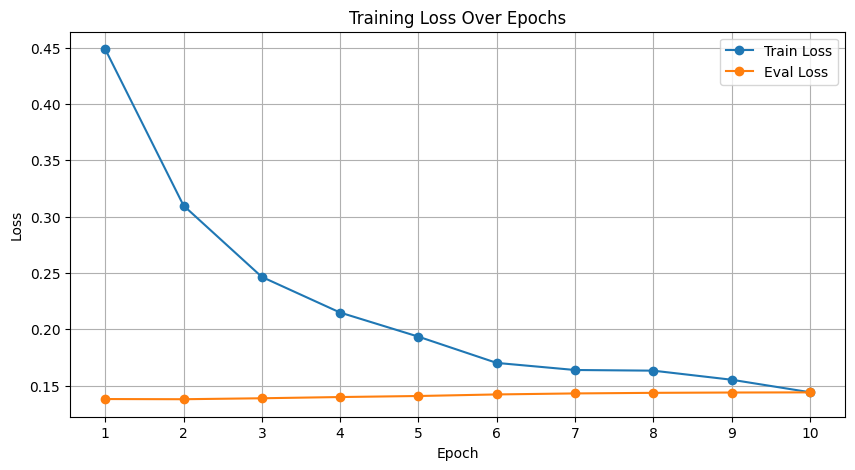

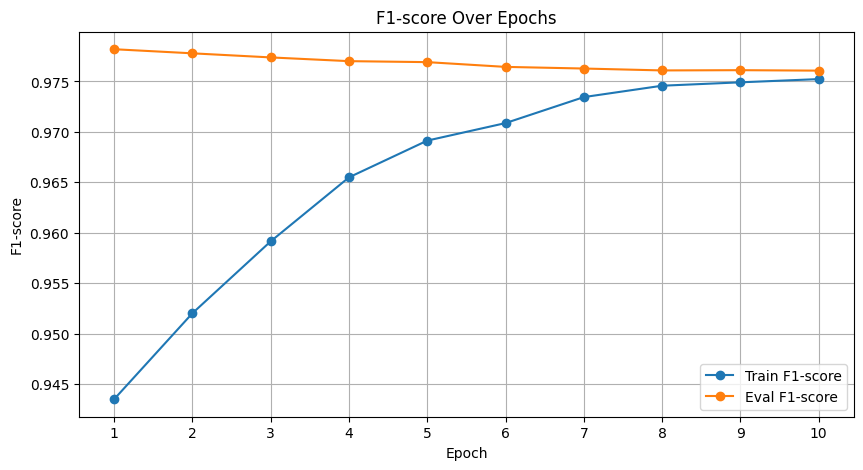

In [43]:
import matplotlib.pyplot as plt

# Shift epoch numbers to start from 1 instead of 0
epochs = list(range(1, len(res["training_stats"]["train_loss"]) + 1))

# Plot training and eval loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, res["training_stats"]["train_loss"], label="Train Loss", marker="o")
if eval_df is not None:
    plt.plot(
        epochs,
        [metrics["loss"] for metrics in res["training_stats"]["eval_metrics"]],
        label="Eval Loss",
        marker="o",
    )  # Add eval loss if available
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid()
plt.savefig(output_dir + "BertMorphV3_training_loss.png")
plt.show()

# Plot training and eval F1-score
plt.figure(figsize=(10, 5))
plt.plot(
    epochs,
    [metrics["f1"] for metrics in res["training_stats"]["train_metrics"]],
    label="Train F1-score",
    marker="o",
)
if eval_df is not None:
    plt.plot(
        epochs,
        [metrics["f1"] for metrics in res["training_stats"]["eval_metrics"]],
        label="Eval F1-score",
        marker="o",
    )  # Add eval F1-score if available
plt.title("F1-score Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.xticks(epochs)
plt.legend()
plt.grid()
plt.savefig(output_dir + "BertMorphV3_f1_score.png")
plt.show()

In [ ]:
train_path = HOMONYMS_DIRS["processed"] / "homonyms_overall_updated.parquet"
# train_path = HOMONYMS_DIRS["processed"] / "homonyms_train_80.parquet"
eval_path = UD_ET_EDT_DIRS["processed"] / "UD_edt_dev.parquet"
model_dir = "../models/NER_mudel_v2/"
output_dir = "../models/NER_mudel_v2_homonym_full_V2/"
ignore_placeholders = True
dry_run = False
seed = 42
train_batch_size = 8
learning_rate = 5e-6  # 5e-7 for fine-tuning
num_train_epochs = 10
use_cuda = torch.cuda.is_available()

In [ ]:
train_df = pd.read_parquet(train_path) if train_path else None
eval_df = pd.read_parquet(eval_path) if eval_path else None

# Read labels from the unique labels json
with open("../outputs/unique_labels_old.json", "r") as f:
    unique_labels = json.load(f)

model_bundle = initialize_model(
    str(model_dir),
    unique_labels=unique_labels,
    use_Roberta_tokenizer=False,
    use_fast_tokenizer=False,
    cleanup=True,
)

E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\utils.py:99: UserWarning: Using label mapping from model `id2label` in checkpoint.
  warnings.warn("Using label mapping from model `id2label` in checkpoint.")


In [ ]:
if train_df is not None:
    print(len(train_df))
    display(train_df.head())
if eval_df is not None:
    print(len(eval_df))
    display(eval_df.head())

179986


,sentence_id,words,form,pos,labels,infl_type,source
0,0,Edinburghi,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,0,agulite,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,0,mehe,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,0,Irvine,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,0,Welshi,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


43997


,sentence_id,words,form,pos,labels,file_prefix,source
0,0,Aga,,J,J,aja_ee199920,et_edt-ud-dev_000.json
1,0,mulle,sg all,P,sg all_P,aja_ee199920,et_edt-ud-dev_000.json
2,0,tundub,b,V,b_V,aja_ee199920,et_edt-ud-dev_000.json
3,0,",",,Z,Z,aja_ee199920,et_edt-ud-dev_000.json
4,0,et,,J,J,aja_ee199920,et_edt-ud-dev_000.json


In [ ]:
# Replace labels that contain "T" with placeholder dash "-"
if eval_df is not None:
    eval_df["labels"] = eval_df["labels"].apply(
        lambda label: "-" if ignore_placeholders and "T" in label else label
    )

In [ ]:
res = train_token_classification(
    model=model_bundle["model"],
    tokenizer=model_bundle["tokenizer"],
    train_df=train_df,
    label_list=unique_labels,
    output_dir=output_dir,
    eval_df=eval_df if eval_df is not None else None,
    num_train_epochs=num_train_epochs,
    train_batch_size=train_batch_size,
    learning_rate=learning_rate,
    evaluate_during_training=False if eval_df is None else True,
    use_early_stopping=False,
    patience_n=1,
    early_stopping_method="f1",
    early_stopping_threshold=0.8,
    best_model_dir=os.path.join(output_dir, "best_model"),
    save_model_every_epoch=True,
    device=model_bundle["device"],
    silent=False,
    max_length=128,
    ignore_placeholders=ignore_placeholders,
    dry_run=dry_run,
    seed=seed,
)

print("Training finished.")

Epoch 1/10: 100%|██████████| 986/986 [01:27<00:00, 11.29it/s, train_loss=0.3084]


train_loss: 0.3084
Epoch 1 train metrics:
 loss=0.1472,  f1=0.9697,  accuracy=0.9696
Epoch 1 train/eval metrics:
 train_loss=0.1472 | eval_loss=0.1452
 train_f1=0.9697 | eval_f1=0.9754
 train_acc=0.9696 | eval_acc=0.9752


Epoch 2/10: 100%|██████████| 986/986 [01:30<00:00, 10.85it/s, train_loss=0.1623]


train_loss: 0.1623
Epoch 2 train metrics:
 loss=0.0809,  f1=0.9822,  accuracy=0.9820
Epoch 2 train/eval metrics:
 train_loss=0.0809 | eval_loss=0.1528
 train_f1=0.9822 | eval_f1=0.9746
 train_acc=0.9820 | eval_acc=0.9743


Epoch 3/10: 100%|██████████| 986/986 [01:27<00:00, 11.23it/s, train_loss=0.1057]


...

train_loss: 0.0125
Epoch 8 train metrics:
 loss=0.0029,  f1=0.9994,  accuracy=0.9994
Epoch 8 train/eval metrics:
 train_loss=0.0029 | eval_loss=0.1692
 train_f1=0.9994 | eval_f1=0.9741
 train_acc=0.9994 | eval_acc=0.9740


Epoch 9/10: 100%|██████████| 986/986 [01:36<00:00, 10.26it/s, train_loss=0.0116]


train_loss: 0.0116
Epoch 9 train metrics:
 loss=0.0023,  f1=0.9995,  accuracy=0.9995
Epoch 9 train/eval metrics:
 train_loss=0.0023 | eval_loss=0.1703
 train_f1=0.9995 | eval_f1=0.9739
 train_acc=0.9995 | eval_acc=0.9737


Epoch 10/10: 100%|██████████| 986/986 [01:35<00:00, 10.27it/s, train_loss=0.0101]


train_loss: 0.0101
Epoch 10 train metrics:
 loss=0.0021,  f1=0.9995,  accuracy=0.9995
Epoch 10 train/eval metrics:
 train_loss=0.0021 | eval_loss=0.1698
 train_f1=0.9995 | eval_f1=0.9738
 train_acc=0.9995 | eval_acc=0.9737
Training finished.


In [ ]:
print("Results:")
print(f"Final training loss: {res['training_stats']['train_loss'][-1]:.4f}")
print(f"Accuracy: {res['training_stats']['train_metrics'][-1]['accuracy']:.2%}")
print(f"Precision: {res['training_stats']['train_metrics'][-1]['precision']:.2%}")
print(f"Recall: {res['training_stats']['train_metrics'][-1]['recall']:.2%}")
print(f"F1-score: {res['training_stats']['train_metrics'][-1]['f1']:.2%}")
if eval_df is not None:
    print(
        f"Final evaluation loss: {res['training_stats']['eval_metrics'][-1]['loss']:.4f}"
    )
    print(
        f"Evaluation Accuracy: {res['training_stats']['eval_metrics'][-1]['accuracy']:.2%}"
    )
    print(
        f"Evaluation Precision: {res['training_stats']['eval_metrics'][-1]['precision']:.2%}"
    )
    print(
        f"Evaluation Recall: {res['training_stats']['eval_metrics'][-1]['recall']:.2%}"
    )
    print(f"Evaluation F1-score: {res['training_stats']['eval_metrics'][-1]['f1']:.2%}")

Results:
Final training loss: 0.0101
Accuracy: 99.95%
Precision: 99.95%
Recall: 99.95%
F1-score: 99.95%
Final evaluation loss: 0.1698
Evaluation Accuracy: 97.37%
Evaluation Precision: 97.47%
Evaluation Recall: 97.37%
Evaluation F1-score: 97.38%


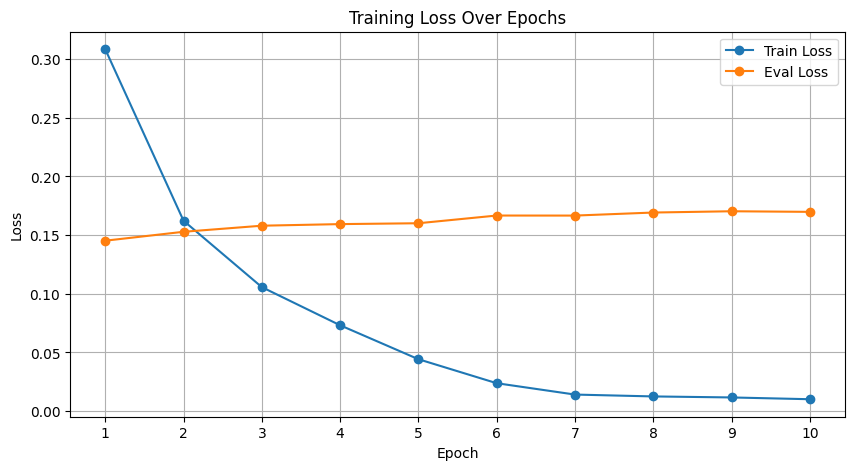

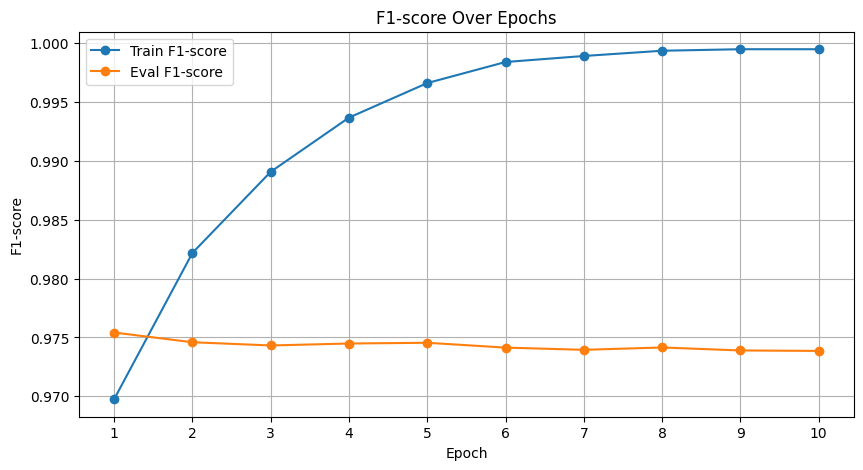

In [68]:
import matplotlib.pyplot as plt

# Shift epoch numbers to start from 1 instead of 0
epochs = list(range(1, len(res["training_stats"]["train_loss"]) + 1))

# Plot training and eval loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, res["training_stats"]["train_loss"], label="Train Loss", marker="o")
if eval_df is not None:
    plt.plot(
        epochs,
        [metrics["loss"] for metrics in res["training_stats"]["eval_metrics"]],
        label="Eval Loss",
        marker="o",
    )  # Add eval loss if available
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid()
plt.savefig(output_dir + "training_loss.png")
plt.show()

# Plot training and eval F1-score
plt.figure(figsize=(10, 5))
plt.plot(
    epochs,
    [metrics["f1"] for metrics in res["training_stats"]["train_metrics"]],
    label="Train F1-score",
    marker="o",
)
if eval_df is not None:
    plt.plot(
        epochs,
        [metrics["f1"] for metrics in res["training_stats"]["eval_metrics"]],
        label="Eval F1-score",
        marker="o",
    )  # Add eval F1-score if available
plt.title("F1-score Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.xticks(epochs)
plt.legend()
plt.grid()
plt.savefig(output_dir + "f1_score.png")
plt.show()